# Griffiths — Introduction to Quantum Mechanics
## Chapter 1: The Wave Function — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--------|:--------|
| [Problem 1.4](#prob_1_4) | Gaussian Wave Packet — Normalization & Uncertainty |
| [Problem 1.5](#prob_1_5) | Double-Exponential Wave Function |
| [Problem 1.9](#prob_1_9) | Classical Harmonic Oscillator Probability Density |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, factorial

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
})
BLUE  = '#2471a3'
RED   = '#c0392b'
GREEN = '#1e8449'
GRAY  = '#7f8c8d'
NAVY  = '#1a3a5c'

figures = []   # collect all Figure objects for saving


---
## Problem 1.4 — Gaussian Wave Packet {#prob_1_4}

Wave function at $t=0$: $\Psi(x,0) = A e^{-ax^2}$, with $A = \left(\dfrac{2a}{\pi}\right)^{1/4}$.

Key results:
- $\langle x \rangle = 0$, $\quad \sigma_x = \dfrac{1}{2\sqrt{a}}$
- $\langle p \rangle = 0$, $\quad \sigma_p = \hbar\sqrt{a}$
- $\sigma_x \sigma_p = \dfrac{\hbar}{2}$ (minimum uncertainty state)


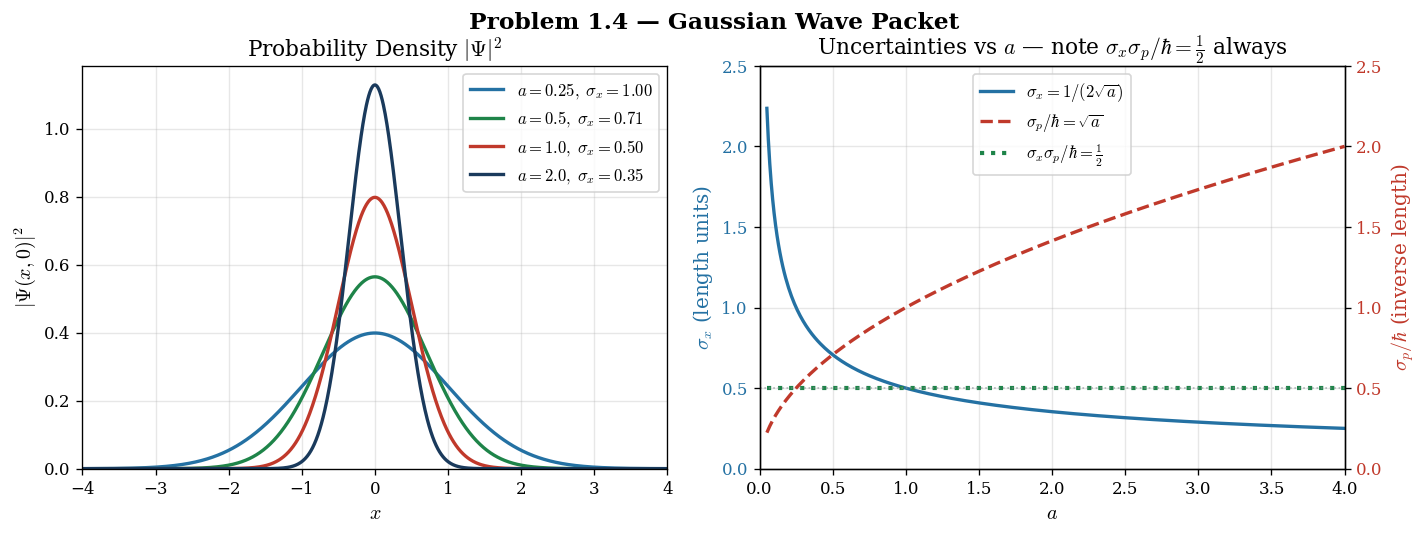

In [2]:
# --- Figure 1.4-A: |Ψ|² shapes (left) + dimensionless uncertainties (right) ---
# FIX: right panel now plots dimensionless σ_x√a and σ_p/(ħ√a),
#      plus their product σ_xσ_p/ħ — all on the SAME dimensionless axis.

x = np.linspace(-4, 4, 1000)
a_vals  = [0.25, 0.5, 1.0, 2.0]
colors4 = [BLUE, GREEN, RED, NAVY]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: |Ψ(x,0)|²
ax = axes[0]
for a, c in zip(a_vals, colors4):
    A   = (2*a / np.pi)**0.25
    psi2 = A**2 * np.exp(-2*a*x**2)
    sx  = 1 / (2*np.sqrt(a))
    ax.plot(x, psi2, color=c, lw=2, label=fr'$a={a},\;\sigma_x={sx:.2f}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$|\Psi(x,0)|^2$')
ax.set_title(r'Probability Density $|\Psi|^2$')
ax.legend()
ax.set_xlim(-4, 4)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

# Right: dimensionless quantities vs a
# σ_x * √a  (dimensionless, = 1/2 always)
# σ_p / (ħ√a)  (dimensionless, = 1 always)
# σ_xσ_p / ħ  (= 1/2 always — the uncertainty bound)
ax2 = axes[1]
a_range = np.linspace(0.05, 4, 400)
sx_dimless = 1/(2*np.sqrt(a_range)) * np.sqrt(a_range)   # = 1/2 (const)
sp_dimless = np.sqrt(a_range) / np.sqrt(a_range)          # = 1   (const)
product    = (1/(2*np.sqrt(a_range))) * np.sqrt(a_range)  # = 1/2 (const)

# Instead show how σ_x and σ_p individually vary with a (non-trivial)
sx_arr = 1 / (2*np.sqrt(a_range))         # has units of length
sp_arr = np.sqrt(a_range)                  # in units of ħ/length
prod   = sx_arr * sp_arr                   # dimensionless (in units of ħ)

ax2_r = ax2.twinx()

l1, = ax2.plot(a_range, sx_arr,  color=BLUE, lw=2,
               label=r'$\sigma_x = 1/(2\sqrt{a})$')
l2, = ax2_r.plot(a_range, sp_arr, color=RED,  lw=2, ls='--',
                 label=r'$\sigma_p/\hbar = \sqrt{a}$')
l3, = ax2.plot(a_range, prod, color=GREEN, lw=2.5, ls=':',
               label=r'$\sigma_x\sigma_p/\hbar = \frac{1}{2}$')
ax2.axhline(0.5, color=GRAY, lw=1, ls=':', alpha=0.6)

ax2.set_xlabel(r'$a$')
ax2.set_ylabel(r'$\sigma_x$ (length units)', color=BLUE)
ax2_r.set_ylabel(r'$\sigma_p/\hbar$ (inverse length)', color=RED)
ax2.set_title(r'Uncertainties vs $a$ — note $\sigma_x\sigma_p/\hbar = \frac{1}{2}$ always')
ax2.tick_params(axis='y', labelcolor=BLUE)
ax2_r.tick_params(axis='y', labelcolor=RED)
ax2.set_xlim(0, 4)
ax2.set_ylim(0, 2.5)
ax2_r.set_ylim(0, 2.5)
lines = [l1, l2, l3]
ax2.legend(lines, [l.get_label() for l in lines], loc='upper center')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 1.4 — Gaussian Wave Packet', fontsize=14, fontweight='bold')
figures.append((fig, 'fig_1_4A.png'))
plt.show()


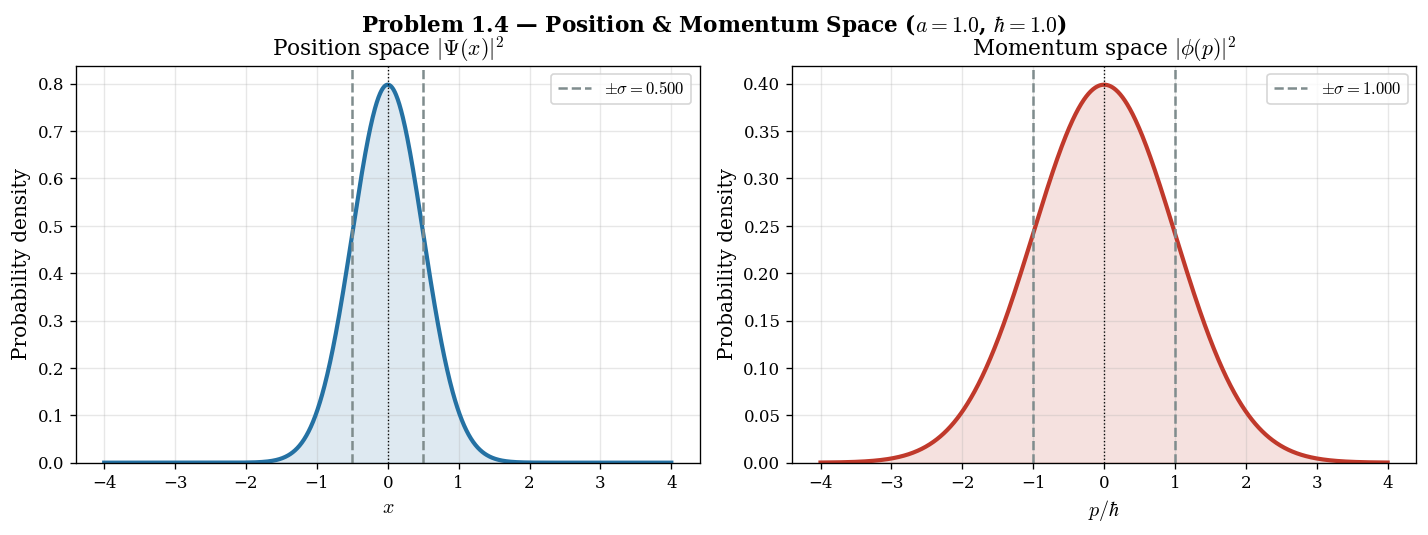

σ_x = 0.5000,  σ_p = 1.0000,  σ_x·σ_p = 0.5000  (ħ/2 = 0.5000)


In [3]:
# --- Figure 1.4-B: Position vs Momentum space (a = 1, ħ = 1) ---
hbar = 1.0
a    = 1.0
A    = (2*a / np.pi)**0.25

x = np.linspace(-4, 4, 1000)
p = np.linspace(-4, 4, 1000)

psi2_x = A**2 * np.exp(-2*a*x**2)
phi2_p = np.sqrt(1/(2*np.pi*a*hbar**2)) * np.exp(-p**2 / (2*a*hbar**2))

sigma_x = 1 / (2*np.sqrt(a))
sigma_p = hbar * np.sqrt(a)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, xarr, yarr, sig, xlabel, title, color in [
    (axes[0], x, psi2_x, sigma_x, r'$x$',        r'Position space $|\Psi(x)|^2$', BLUE),
    (axes[1], p, phi2_p, sigma_p, r'$p/\hbar$',   r'Momentum space $|\phi(p)|^2$', RED),
]:
    ax.plot(xarr, yarr, color=color, lw=2.5)
    ax.fill_between(xarr, yarr, alpha=0.15, color=color)
    ax.axvline( sig, color=GRAY, ls='--', lw=1.5, label=fr'$\pm\sigma = {sig:.3f}$')
    ax.axvline(-sig, color=GRAY, ls='--', lw=1.5)
    ax.axvline(0,    color='k',  ls=':',  lw=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability density')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle(fr'Problem 1.4 — Position & Momentum Space ($a={a}$, $\hbar={hbar}$)',
             fontsize=13, fontweight='bold')
figures.append((fig, 'fig_1_4B.png'))
plt.show()
print(f'σ_x = {sigma_x:.4f},  σ_p = {sigma_p:.4f},  '
      f'σ_x·σ_p = {sigma_x*sigma_p:.4f}  (ħ/2 = {hbar/2:.4f})')


---
## Problem 1.5 — Double-Exponential Wave Function {#prob_1_5}

Wave function: $\Psi(x,0) = \sqrt{a}\,e^{-a|x|}$

Key results:
- $\langle x \rangle = 0$, $\quad \sigma_x = \dfrac{1}{a\sqrt{2}}$
- $\langle p \rangle = 0$, $\quad \sigma_p = \hbar a$
- $\sigma_x \sigma_p = \dfrac{\hbar}{\sqrt{2}} > \dfrac{\hbar}{2}$ (does **not** saturate bound)


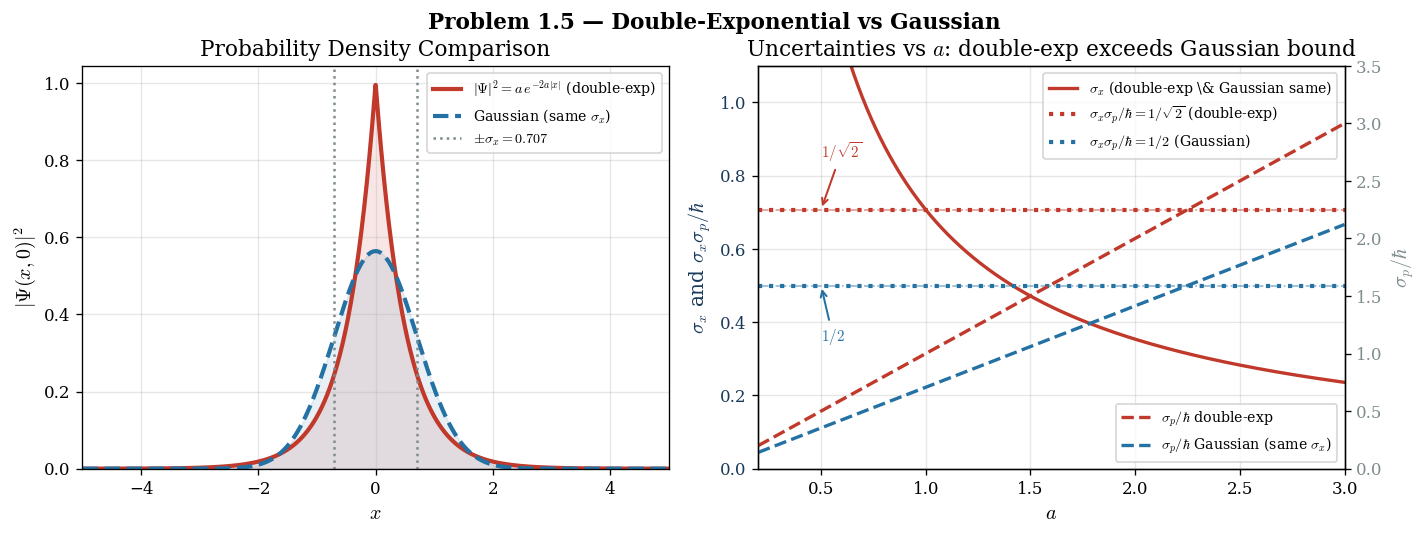

Double-exp: σ_x·σ_p/ħ = 1/√2 = 0.7071
Gaussian:   σ_x·σ_p/ħ = 1/2  = 0.5000
Ratio: 1.4142  (= √2 ≈ 1.4142)


In [4]:
# --- Figure 1.5: Double-Exponential vs Gaussian ---
# FIX: right panel now shows how σ_x and σ_p each vary with a (non-trivial),
#      with twin axes to avoid mixing dimensions, and constant product lines.

hbar = 1.0
a    = 1.0
x    = np.linspace(-5, 5, 2000)

psi2_dexp  = a * np.exp(-2*a*np.abs(x))
sigma_x_d  = 1 / (a * np.sqrt(2))
sigma_p_d  = hbar * a

# Gaussian with same σ_x
a_g         = 1 / (4 * sigma_x_d**2)
psi2_gauss  = (2*a_g/np.pi)**0.5 * np.exp(-2*a_g*x**2)
sigma_p_g   = hbar * np.sqrt(a_g)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: probability density comparison
ax = axes[0]
ax.plot(x, psi2_dexp,  color=RED,  lw=2.5,
        label=r'$|\Psi|^2 = a\,e^{-2a|x|}$ (double-exp)')
ax.plot(x, psi2_gauss, color=BLUE, lw=2.5, ls='--',
        label=r'Gaussian (same $\sigma_x$)')
ax.axvline( sigma_x_d, color=GRAY, ls=':', lw=1.5)
ax.axvline(-sigma_x_d, color=GRAY, ls=':', lw=1.5,
           label=fr'$\pm\sigma_x = {sigma_x_d:.3f}$')
ax.fill_between(x, psi2_dexp,  alpha=0.12, color=RED)
ax.fill_between(x, psi2_gauss, alpha=0.10, color=BLUE)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$|\Psi(x,0)|^2$')
ax.set_title('Probability Density Comparison')
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(bottom=0)

# Right: σ_x and σ_p vs a with twin axes, plus constant product lines
# FIX: σ_x (length) on left axis, σ_p/ħ (inverse length) on right axis
#      Two horizontal product reference lines show the different bounds.
a_arr = np.linspace(0.2, 3, 400)
sx_d  = 1 / (a_arr * np.sqrt(2))        # double-exp σ_x
sp_d  = hbar * a_arr                     # double-exp σ_p  (in units of ħ)
sx_g  = 1 / (a_arr * np.sqrt(2))        # same σ_x for Gaussian (by construction)
sp_g  = hbar * np.sqrt(a_arr / 2)       # Gaussian σ_p = ħ√(a_g) = ħ/√(2)*√(a)...
# Actually for Gaussian with same σ_x = 1/(a√2): a_g = 1/(4σ_x²) = a²/2
# σ_p_gauss = ħ√(a_g) = ħ·a/√2
sp_g  = hbar * a_arr / np.sqrt(2)

prod_d = sx_d * sp_d / hbar    # = 1/√2 (constant)
prod_g = sx_g * sp_g / hbar    # = 1/2  (constant)

ax2   = axes[1]
ax2_r = ax2.twinx()

l1, = ax2.plot(a_arr, sx_d,  color=RED,  lw=2,
               label=r'$\sigma_x$ (double-exp \& Gaussian same)')
l2, = ax2_r.plot(a_arr, sp_d/hbar, color=RED,  lw=2, ls='--',
                 label=r'$\sigma_p/\hbar$ double-exp')
l3, = ax2_r.plot(a_arr, sp_g/hbar, color=BLUE, lw=2, ls='--',
                 label=r'$\sigma_p/\hbar$ Gaussian (same $\sigma_x$)')
l4, = ax2.plot(a_arr, prod_d, color=RED,  lw=2.5, ls=':',
               label=r'$\sigma_x\sigma_p/\hbar = 1/\sqrt{2}$ (double-exp)')
l5, = ax2.plot(a_arr, prod_g, color=BLUE, lw=2.5, ls=':',
               label=r'$\sigma_x\sigma_p/\hbar = 1/2$ (Gaussian)')
ax2.axhline(1/np.sqrt(2), color=RED,  lw=1, ls='-.', alpha=0.5)
ax2.axhline(0.5,          color=BLUE, lw=1, ls='-.', alpha=0.5)
ax2.annotate(r'$1/\sqrt{2}$', xy=(0.5, 1/np.sqrt(2)),
             xytext=(0.5, 0.85), color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.2), fontsize=9)
ax2.annotate(r'$1/2$', xy=(0.5, 0.5),
             xytext=(0.5, 0.35), color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2), fontsize=9)

ax2.set_xlabel(r'$a$')
ax2.set_ylabel(r'$\sigma_x$ and $\sigma_x\sigma_p/\hbar$', color=NAVY)
ax2_r.set_ylabel(r'$\sigma_p / \hbar$', color=GRAY)
ax2.set_title(r'Uncertainties vs $a$: double-exp exceeds Gaussian bound')
ax2.tick_params(axis='y', labelcolor=NAVY)
ax2_r.tick_params(axis='y', labelcolor=GRAY)
ax2.set_xlim(0.2, 3)
ax2.set_ylim(0, 1.1)
ax2_r.set_ylim(0, 3.5)
ax2.legend(handles=[l1,l4,l5], loc='upper right', fontsize=8.5)
ax2_r.legend(handles=[l2,l3], loc='lower right', fontsize=8.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 1.5 — Double-Exponential vs Gaussian',
             fontsize=13, fontweight='bold')
figures.append((fig, 'fig_1_5.png'))
plt.show()

print(f'Double-exp: σ_x·σ_p/ħ = 1/√2 = {1/np.sqrt(2):.4f}')
print(f'Gaussian:   σ_x·σ_p/ħ = 1/2  = {0.5:.4f}')
print(f'Ratio: {(1/np.sqrt(2))/0.5:.4f}  (= √2 ≈ {np.sqrt(2):.4f})')


---
## Problem 1.9 — Classical Harmonic Oscillator Probability Density {#prob_1_9}

Classical trajectory: $x(t) = A\sin(\omega t)$

Classical probability density: $\rho(x) = \dfrac{1}{\pi\sqrt{A^2 - x^2}}$

Quantum ground state: $|\Psi_0(x)|^2 = \dfrac{1}{\sqrt{\pi}\,\ell}\,e^{-x^2/\ell^2}$, where $\ell = \sqrt{\hbar/(m\omega)}$

The two distributions look strikingly different — a key signature of the quantum-classical transition.


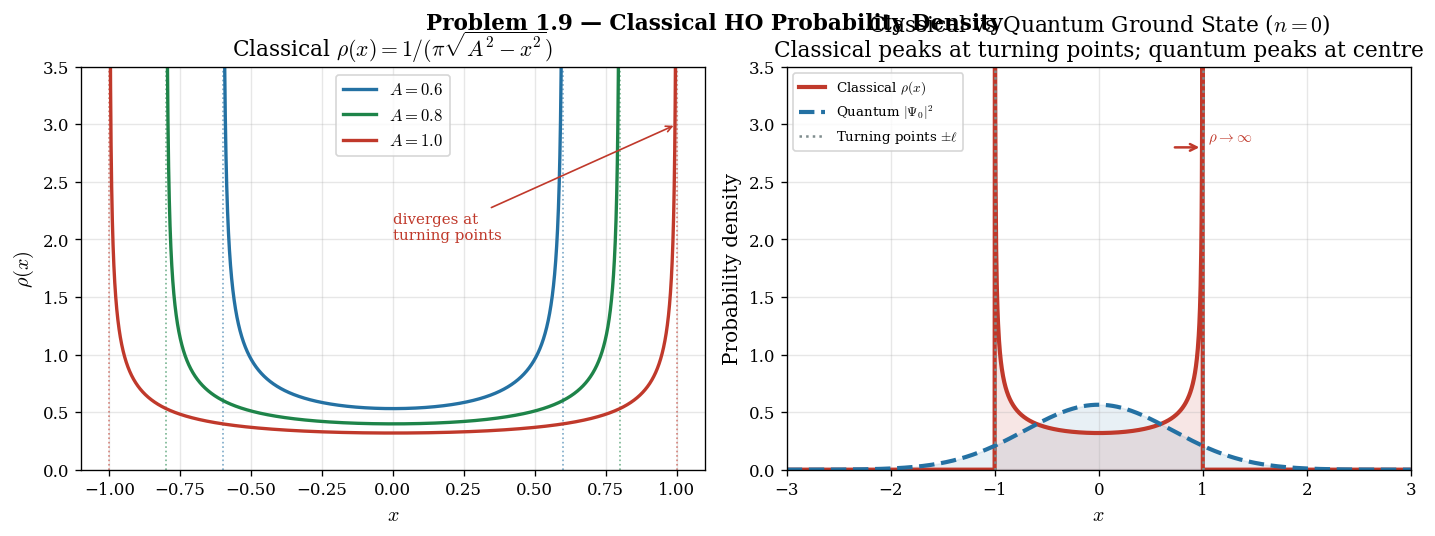

In [5]:
# --- Figure 1.9-A: Classical ρ(x) for different amplitudes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x_fine  = np.linspace(-1, 1, 10000)
A_vals  = [0.6, 0.8, 1.0]
colors2 = [BLUE, GREEN, RED]

ax = axes[0]
for A, c in zip(A_vals, colors2):
    mask = np.abs(x_fine) < A - 1e-6
    rho  = np.zeros_like(x_fine)
    rho[mask] = 1 / (np.pi * np.sqrt(A**2 - x_fine[mask]**2))
    ax.plot(x_fine[mask], rho[mask], color=c, lw=2, label=fr'$A = {A}$')
    # Mark turning points
    ax.axvline( A, color=c, ls=':', lw=1, alpha=0.6)
    ax.axvline(-A, color=c, ls=':', lw=1, alpha=0.6)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\rho(x)$')
ax.set_title(r'Classical $\rho(x) = 1/(\pi\sqrt{A^2-x^2})$')
ax.set_ylim(0, 3.5)
ax.legend()
ax.grid(True, alpha=0.3)
ax.annotate('diverges at\nturning points', xy=(1.0, 3.0),
            xytext=(0.0, 2.0), fontsize=9, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))

# --- Classical vs Quantum ground state (n=0) ---
# FIX: raise y-limit to show the divergence near turning points clearly
ax2 = axes[1]
hbar, m, omega = 1.0, 1.0, 1.0
ell  = np.sqrt(hbar / (m * omega))
A_cl = ell   # classical turning point for E_0 = ħω/2

x_plot  = np.linspace(-3*ell, 3*ell, 2000)
mask_cl = np.abs(x_plot) < A_cl - 1e-8
rho_cl  = np.zeros_like(x_plot)
rho_cl[mask_cl] = 1 / (np.pi * np.sqrt(A_cl**2 - x_plot[mask_cl]**2))
rho_q0  = (1/(np.sqrt(np.pi)*ell)) * np.exp(-x_plot**2/ell**2)

ax2.plot(x_plot, rho_cl, color=RED,  lw=2.5, label=r'Classical $\rho(x)$')
ax2.fill_between(x_plot[mask_cl], rho_cl[mask_cl], alpha=0.12, color=RED)
ax2.plot(x_plot, rho_q0, color=BLUE, lw=2.5, ls='--', label=r'Quantum $|\Psi_0|^2$')
ax2.fill_between(x_plot, rho_q0, alpha=0.10, color=BLUE)
ax2.axvline( A_cl, color=GRAY, ls=':', lw=1.5, label=fr'Turning points $\pm\ell$')
ax2.axvline(-A_cl, color=GRAY, ls=':', lw=1.5)
ax2.annotate('', xy=(A_cl, 2.8), xytext=(A_cl-0.3, 2.8),
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))
ax2.annotate(r'$\rho\to\infty$', xy=(A_cl+0.05, 2.85), fontsize=9, color=RED)
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'Probability density')
ax2.set_title('Classical vs Quantum Ground State ($n=0$)\n'
              r'Classical peaks at turning points; quantum peaks at centre')
# FIX: raise y limit to show the divergence behaviour
ax2.set_ylim(0, 3.5)
ax2.set_xlim(-3*ell, 3*ell)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 1.9 — Classical HO Probability Density',
             fontsize=13, fontweight='bold')
figures.append((fig, 'fig_1_9A.png'))
plt.show()


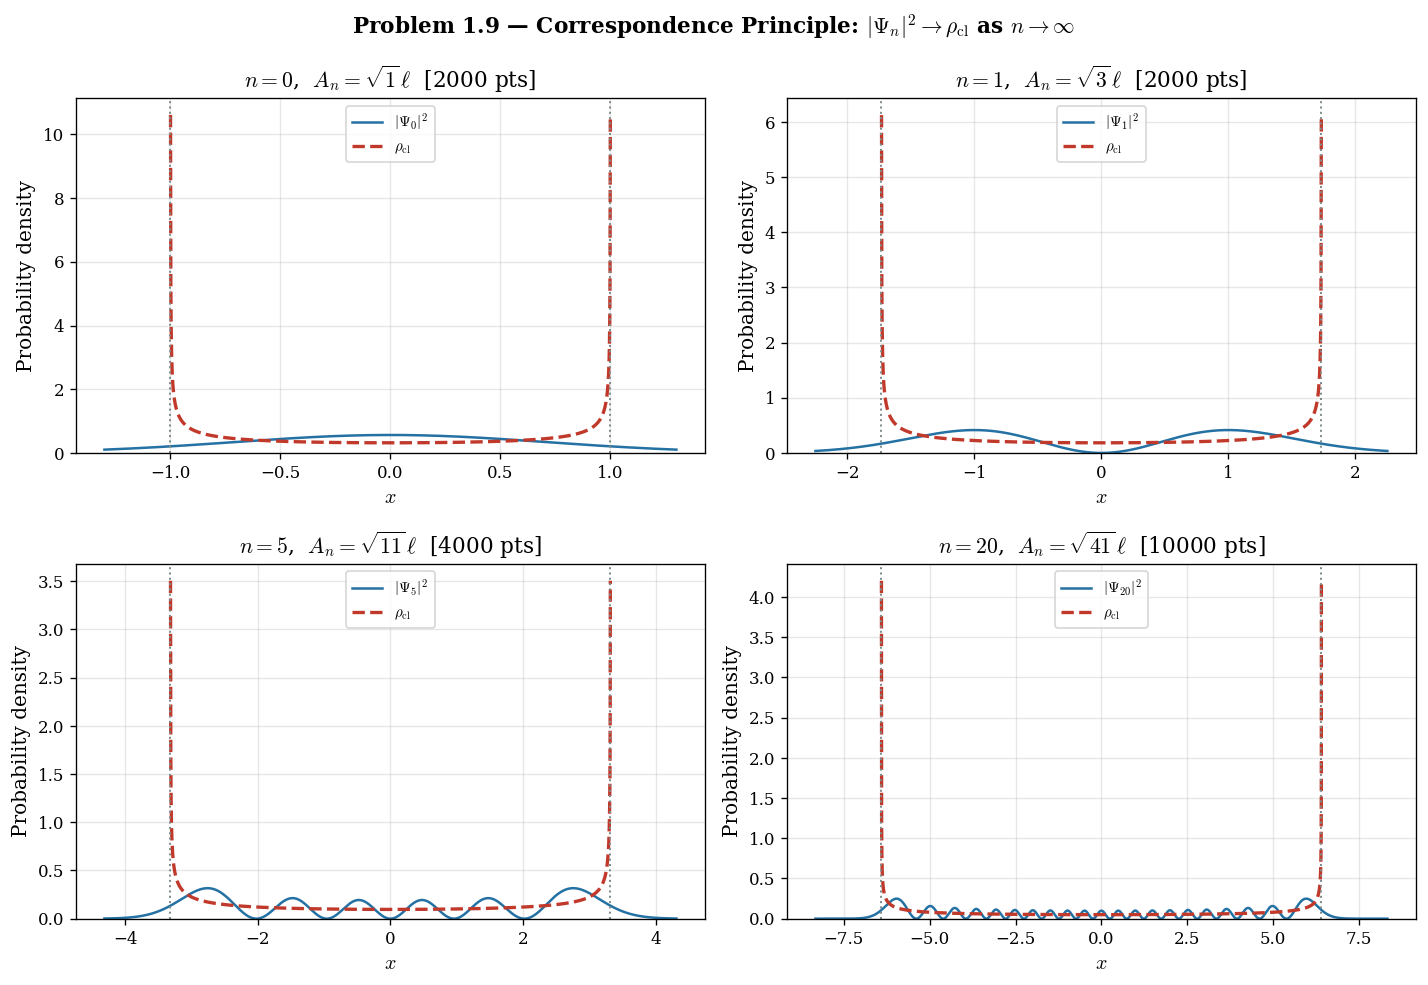

As n increases, the quantum PDF oscillates around the classical ρ_cl.
The coarse-grained average converges → Bohr correspondence principle.


In [6]:
# --- Figure 1.9-B: Correspondence Principle (n = 0, 1, 5, 20) ---
# FIX: n=20 uses 10000 points to resolve high-frequency oscillations

def quantum_HO(x, n, ell=1.0):
    xi = x / ell
    Hn = hermite(n)(xi)
    norm = 1 / (np.sqrt(np.pi) * ell * 2**n * factorial(n))
    return norm * Hn**2 * np.exp(-xi**2)

hbar = m = omega = 1.0
ell  = np.sqrt(hbar/(m*omega))

n_vals = [0, 1, 5, 20]
# FIX: high-n gets more points for faithful oscillation rendering
npts   = [2000, 2000, 4000, 10000]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (n, np_) in enumerate(zip(n_vals, npts)):
    ax  = axes[idx]
    A_n = np.sqrt(2*n + 1) * ell
    x_plot = np.linspace(-1.3*A_n, 1.3*A_n, np_)

    rho_q = quantum_HO(x_plot, n, ell)

    mask  = np.abs(x_plot) < A_n - 1e-8
    rho_c = np.zeros_like(x_plot)
    rho_c[mask] = 1 / (np.pi * np.sqrt(A_n**2 - x_plot[mask]**2))

    ax.plot(x_plot, rho_q, color=BLUE, lw=1.5, label=fr'$|\Psi_{{{n}}}|^2$')
    ax.plot(x_plot[mask], rho_c[mask], color=RED, lw=2, ls='--',
            label=r'$\rho_{\rm cl}$')
    ax.axvline( A_n, color=GRAY, ls=':', lw=1.2)
    ax.axvline(-A_n, color=GRAY, ls=':', lw=1.2)
    ax.set_title(fr'$n = {n}$,  $A_n = \sqrt{{{2*n+1}}}\,\ell$  '
                 fr'[{np_} pts]')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel('Probability density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0)

plt.suptitle(r'Problem 1.9 — Correspondence Principle: $|\Psi_n|^2 \to \rho_{\rm cl}$ as $n\to\infty$',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
figures.append((fig, 'fig_1_9B.png'))
plt.show()
print('As n increases, the quantum PDF oscillates around the classical ρ_cl.')
print('The coarse-grained average converges → Bohr correspondence principle.')


---
## Save All Figures & Download as ZIP


In [7]:
# --- Save all figures and download as zip ---
import os, zipfile

save_dir = 'ch01_figures'
os.makedirs(save_dir, exist_ok=True)

for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

zip_name = 'ch01_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'\nZip created: {zip_name}')
print(f'Files: {[f for _,f in figures]}')

# Download in Colab
try:
    from google.colab import files

    # AUTO-INJECTED: Korean font setup for matplotlib
    import os as _os
    import matplotlib.font_manager as _fm
    import matplotlib.pyplot as _plt
    if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
        for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
            if _os.path.exists(_font):
                _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    del _os, _fm, _plt
    # END AUTO-INJECTED Korean font setup

    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — file saved locally as: {zip_name}')


Saved: ch01_figures/fig_1_4A.png
Saved: ch01_figures/fig_1_4B.png
Saved: ch01_figures/fig_1_5.png
Saved: ch01_figures/fig_1_9A.png
Saved: ch01_figures/fig_1_9B.png

Zip created: ch01_figures.zip
Files: ['fig_1_4A.png', 'fig_1_4B.png', 'fig_1_5.png', 'fig_1_9A.png', 'fig_1_9B.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
